In [1]:
# Thiranex Internship - Project 2
# Predictive Modeling Using Machine Learning
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score
)
print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load the Breast Cancer dataset
data = load_breast_cancer()
# Convert into a pandas DataFrame
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")
print("Dataset loaded successfully!")
print("Number of rows:", X.shape[0])
print("Number of features:", X.shape[1])

Dataset loaded successfully!
Number of rows: 569
Number of features: 30


In [3]:
# Display the first 5 rows
X.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [4]:
# Display target information
print("Target classes:")
print(data.target_names)
print("\nTarget distribution:")
print(y.value_counts())

Target classes:
['malignant' 'benign']

Target distribution:
target
1    357
0    212
Name: count, dtype: int64


In [5]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)
print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 455
Testing samples: 114


In [6]:
# Create the Random Forest classifier
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
# Train the model
model.fit(X_train, y_train)
print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [7]:
# Make predictions on the test data
y_pred = model.predict(X_test)
print("Predictions completed successfully!")
print("First 10 predictions:")
print(y_pred[:10])

Predictions completed successfully!
First 10 predictions:
[0 1 0 0 0 1 1 0 0 0]


In [8]:
# Calculate model accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Model Accuracy:", round(accuracy * 100, 2), "%")

Model Accuracy: 95.61 %


In [9]:
# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[39  3]
 [ 2 70]]


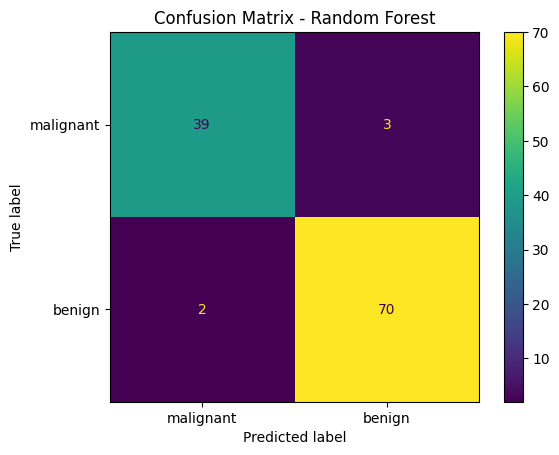

In [10]:
# Visualize the confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=data.target_names
)
disp.plot()
plt.title("Confusion Matrix - Random Forest")
plt.show()

In [11]:
# Generate classification report
print("Classification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=data.target_names
    )
)

Classification Report:
              precision    recall  f1-score   support

   malignant       0.95      0.93      0.94        42
      benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



In [12]:
# Predict probabilities for ROC curve
y_prob = model.predict_proba(X_test)[:, 1]
# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
# Calculate AUC
auc_score = roc_auc_score(y_test, y_prob)
print("ROC-AUC Score:", round(auc_score, 4))

ROC-AUC Score: 0.9937


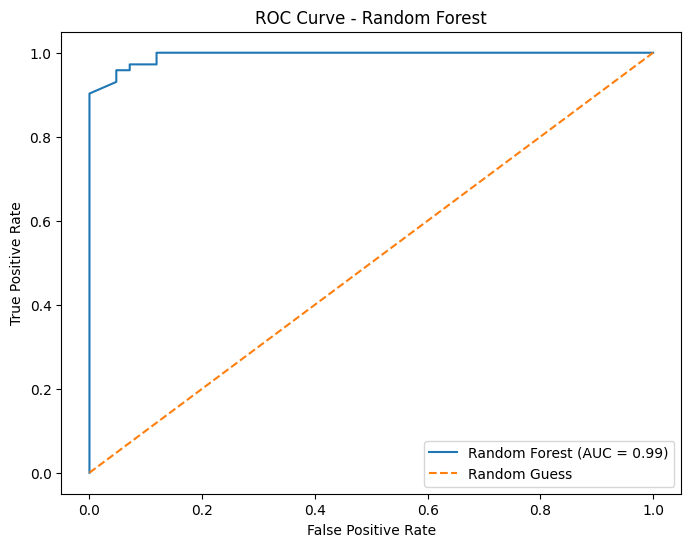

In [13]:
# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(
    fpr,
    tpr,
    label=f"Random Forest (AUC = {auc_score:.2f})"
)
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Guess"
)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()
plt.show()

In [14]:
# Get feature importance
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})
# Sort by importance
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)
print("Top 10 Important Features:")
print(feature_importance.head(10))

Top 10 Important Features:
                 Feature  Importance
23            worst area    0.140016
27  worst concave points    0.129530
20          worst radius    0.097696
7    mean concave points    0.090885
22       worst perimeter    0.072226
2         mean perimeter    0.069574
0            mean radius    0.068676
6         mean concavity    0.057638
3              mean area    0.049172
26       worst concavity    0.034340


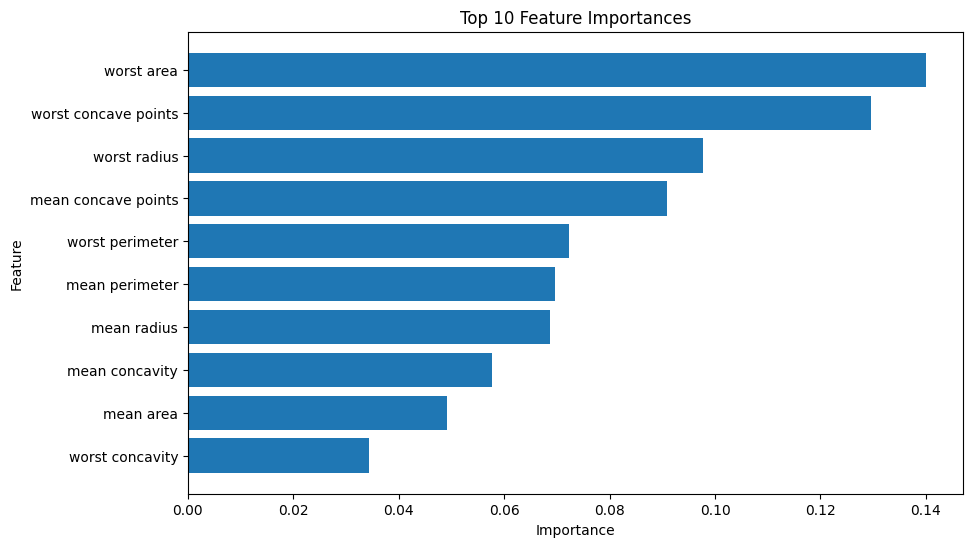

In [15]:
# Visualize top 10 important features
top_features = feature_importance.head(10)
plt.figure(figsize=(10, 6))
plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Feature Importances")
plt.show()

## Conclusion

In this project, a Random Forest Classification model was developed using the Breast Cancer Wisconsin dataset.

The dataset was divided into training and testing sets. The Random Forest model was trained using the training data and evaluated using the test data.

Model performance was evaluated using accuracy, confusion matrix, classification report, and ROC-AUC score. The results demonstrate that the model can effectively classify the target classes.

Feature importance was also analyzed to identify the features that contributed most to the model's predictions.

Overall, this project demonstrates the complete predictive modeling workflow, including data preparation, model training, prediction, evaluation, and visualization.